I. Introduction & Structural Motivation
* The Research Question: Timing song releases to maximize NPV in a crowded digital market.
* The Logic: Cite Rust (1987) and Einav (2007).
* The Functional Form: Define the Double-Exponential (Bass-style) Diffusion model for streams.
    * $S_{ia} = A_i(x_\tau) \cdot [ \exp(-\gamma_i a) - \exp(-\alpha_i a) ] + \epsilon_{ia}$


$$V(x_t) = \max \left\{ \underbrace{\mathbb{E} \left[ \sum_{\tau=t}^{\infty} \beta^{\tau-t} R(x_t, S_{i,\tau-t}) \right]}_{\text{Release Now}}, \underbrace{\beta \mathbb{E} [V(x_{t+1}) | x_t]}_{\text{Wait}} \right\}$$

Where $R$ is revenue, $x_t$ is the market state, and $S_{i,\tau-t}$ is daily streaming volume for track $i$.



II. Data Pipeline & Web Scraping (Tool Practice)
* Data Integration: Merge the Kaggle charts.csv with Spotify API metadata.
* Feature Engineering: Constructing the "Stochastic Process" ($x_t$):
* Genre-specific "Market Heat" indices.
    * Competitor count variables.
    * Handling "off-chart" tracks via zero-padding (addressing the censoring issue).


In [1]:
%pip install python-dotenv kaggle spotipy pandas matplotlib numpy statsmodels scipy scikit-learn jax optax torch seaborn


Note: you may need to restart the kernel to use updated packages.


In [2]:
#Data Integration: Merge the Kaggle charts.csv with Spotify API metadata.
from download_kaggle_data import download_kaggle_data

download_kaggle_data("maharshipandya/-spotify-tracks-dataset")
download_kaggle_data("jfreyberg/spotify-chart-data")


ConnectionError: HTTPSConnectionPool(host='api.kaggle.com', port=443): Max retries exceeded with url: /v1/security.OAuthService/IntrospectToken (Caused by NameResolutionError("HTTPSConnection(host='api.kaggle.com', port=443): Failed to resolve 'api.kaggle.com' ([Errno 11001] getaddrinfo failed)"))

Rows in original charts: 5428021
Rows after inner merge: 1336013
count    1.336013e+06
mean     4.709669e+02
std      6.149870e+02
min      0.000000e+00
25%      9.800000e+01
50%      2.450000e+02
75%      5.530000e+02
max      3.546000e+03
Name: age_days, dtype: float64


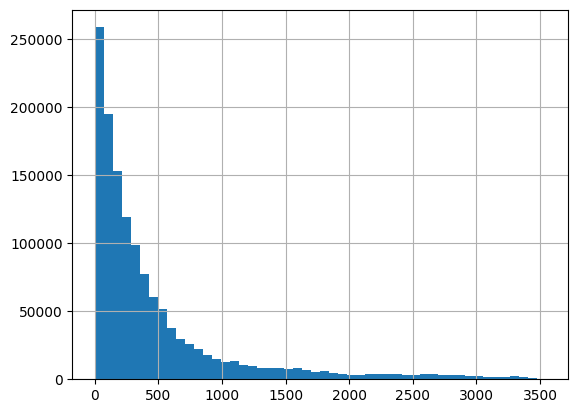

In [1]:
import pandas as pd
import numpy as np


# Load your data
charts_df = pd.read_csv('../data/charts.csv')
dataset_df = pd.read_csv('../data/dataset.csv')

# Drop duplicates
dataset_df = dataset_df.drop_duplicates(subset='track_id')

# Perform the Inner Join
merged_df = pd.merge(charts_df, dataset_df, on='track_id', how='inner')

print(f"Rows in original charts: {len(charts_df)}")
print(f"Rows after inner merge: {len(merged_df)}")

# Step 1: Ensure the original 'date' is a datetime object first
merged_df['date'] = pd.to_datetime(merged_df['date'], format='mixed')

# Step 2: Create the proxy dates (the first time each track appeared)
proxy_dates = merged_df.groupby('track_id')['date'].min().reset_index()
proxy_dates.columns = ['track_id', 'approx_release_date']

# Step 3: Now merge the proxy dates BACK into the main dataframe
merged_df = pd.merge(merged_df, proxy_dates, on='track_id')

# Step 4: Calculate Age
merged_df['age_days'] = (merged_df['date'] - merged_df['approx_release_date']).dt.days

# Check the distribution
print(merged_df['age_days'].describe())

# Plot a quick histogram to see the 'decay' potential
merged_df['age_days'].hist(bins=50)

# 1. Aggregate daily/weekly streams to get 'Market Heat'
# We group by the chart date to see the total activity in the market
market_heat = merged_df.groupby('date')['streams'].sum().reset_index()
market_heat.columns = ['date', 'x_t']

#adding genre specific heat
genre_heat = merged_df.groupby(['date', 'track_genre'])['streams'].sum().reset_index()
genre_heat.columns = ['date', 'track_genre', 'x_g_t']


# Merge the aggregate heat back to the main dataframe
merged_state_df = pd.merge(merged_df, market_heat, on='date', how='inner')
# Then the genre heat (matches on both date and genre)
merged_state_df = pd.merge(merged_state_df, genre_heat, on=['date', 'track_genre'], how='left')

merged_state_df['log_x_t'] = np.log(merged_state_df['x_t'])
merged_state_df['log_x_g_t'] = np.log(merged_state_df['x_g_t'])

"Due to API constraints (24 hour lockout for rate violations), the release date for tracks in the sample was approximated using the date of the track's first appearance on the Spotify Charts, rather than directly from Spotify."

Feature Engineering: Constructing the "Stochastic Process" ($x_t$):
This includes: market heat, competitor releases, genre trends

In [2]:
import ast

def fix_artist_column(val):
    # If it's already a list, keep it
    if isinstance(val, list):
        return val
    # If it's a string that looks like a list, convert it
    if isinstance(val, str):
        val = val.strip()
        if val.startswith('[') and val.endswith(']'):
            try:
                return ast.literal_eval(val)
            except:
                # If literal_eval fails, try manual splitting
                return [a.strip("'\" ") for a in val[1:-1].split(',')]
        return [val] # Treat single name strings as a 1-item list
    return []

# Apply the fix
merged_state_df['artists_x'] = merged_state_df['artists_x'].apply(fix_artist_column)

# VERIFICATION: This must be higher than the original count now
exploded_df = merged_state_df.explode('artists_x')
print(f"Original rows: {len(merged_state_df)}")
print(f"Exploded rows: {len(exploded_df)}")

# 1. Calculate the 'Power' of every individual artist
artist_power = exploded_df.groupby('artists_x')['streams'].mean().to_dict()

# 2. Pick the 'Alpha' artist for every track
def get_alpha(artist_list):
    # Find the artist in the list with the highest mean streams
    return max(artist_list, key=lambda x: artist_power.get(x, 0))

merged_state_df['dominant_artist'] = merged_state_df['artists_x'].apply(get_alpha)

print("Dominant Artists found:")
print(merged_state_df['dominant_artist'].value_counts().head(10))

# 1. Identify top 50 dominant artists to use as Fixed Effects
top_50_names = merged_state_df['dominant_artist'].value_counts().nlargest(50).index

# 2. Create a 'Group' column: Artist Name or 'Other'
merged_state_df['fe_group'] = merged_state_df['dominant_artist'].apply(
    lambda x: x if x in top_50_names else 'Other'
)

# 3. Create Dummy Matrix (drop_first=True to avoid the Dummy Variable Trap)
artist_dummies = pd.get_dummies(merged_state_df['fe_group'], prefix='art', drop_first=True)
dummy_cols = artist_dummies.columns.tolist()

# 4. Join back to the main dataframe
merged_state_df = pd.concat([merged_state_df, artist_dummies], axis=1)



Original rows: 1336013
Exploded rows: 2112730
Dominant Artists found:
dominant_artist
Bad Bunny           53886
Dua Lipa            32287
Billie Eilish       30137
The Weeknd          29505
XXXTENTACION        26304
Ed Sheeran          23731
The Chainsmokers    20922
Halsey              18991
Travis Scott        18676
Ariana Grande       18542
Name: count, dtype: int64


In [14]:
def add_daily_streams_column(df):
    # 1. Standardize and Clean
    df['date'] = pd.to_datetime(df['date'])
    group_cols = ['fe_group', 'track_name']
    
    # CRITICAL: Remove duplicate dates within the same song
    # We keep the 'last' because it usually has the most recent stream tally
    df = df.sort_values(group_cols + ['date', 'streams'])
    df = df.drop_duplicates(subset=group_cols + ['date'], keep='last')

    # 2. Calculate the deltas
    # We sort again just to be safe
    df = df.sort_values(group_cols + ['date'])
    
    # Calculate stream difference and day difference
    df['delta_streams'] = df.groupby(group_cols)['streams'].diff()
    df['delta_days'] = df.groupby(group_cols)['date'].diff().dt.days

    # 3. Calculate Daily Flow
    # With duplicates removed, delta_days will be >= 1 or NaN (for the first row)
    df['daily_streams'] = df['delta_streams'] / df['delta_days']

    # 4. Final Cleanup
    # Fill first-day NaNs and clip negatives (in case of data corrections)
    df['daily_streams'] = df['daily_streams'].fillna(0).replace([np.inf, -np.inf], 0).clip(lower=0)

    # Remove temporary calculation columns
    return df.drop(columns=['delta_streams', 'delta_days'])

# Usage
est_df_daily = add_daily_streams_column(merged_state_df)

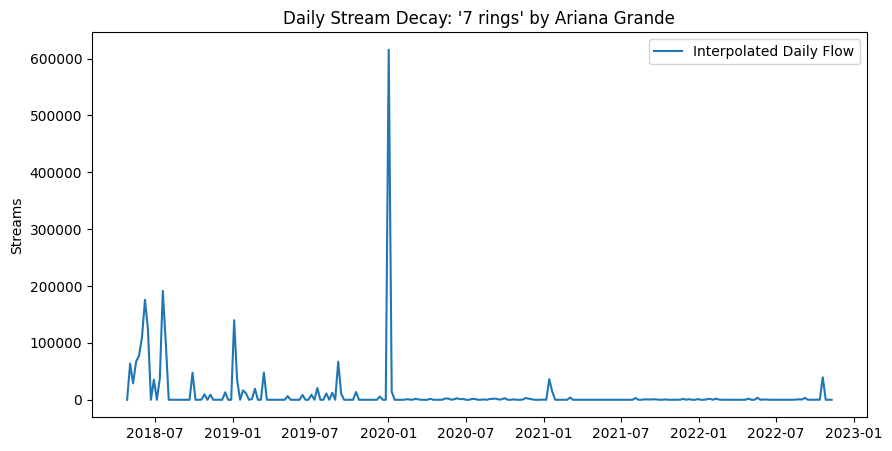

In [ ]:
import matplotlib.pyplot as plt

# Filter for one specific track
song_df = est_df_daily[
    (est_df_daily['fe_group'] == 'Anne-Marie') & 
    (est_df_daily['track_id'] == '2BgEsaKNfHUdlh97KmvFyo')
]

plt.figure(figsize=(10, 5))
plt.plot(song_df['date'], song_df['daily_streams'], label='Interpolated Daily Flow')
plt.title("Daily Stream Decay")
plt.ylabel("Streams")
plt.legend()
plt.show()

In [16]:
# 1. Aggregate daily/weekly streams to get 'Market Heat'
# We group by the chart date to see the total activity in the market
market_heat = est_df_daily.groupby('date')['daily_streams'].sum().reset_index()
market_heat.columns = ['date', 'x_t_daily']

#adding genre specific heat
genre_heat = est_df_daily.groupby(['date', 'track_genre'])['streams'].sum().reset_index()
genre_heat.columns = ['date', 'track_genre', 'x_g_t_daily']


# Merge the aggregate heat back to the main dataframe
est_df_daily = pd.merge(est_df_daily, market_heat, on='date', how='inner')
# Then the genre heat (matches on both date and genre)
est_df_daily = pd.merge(est_df_daily, genre_heat, on=['date', 'track_genre'], how='left')

est_df_daily['log_x_t_daily'] = np.log(est_df_daily['x_t_daily'])
est_df_daily['log_x_g_t_daily'] = np.log(est_df_daily['x_g_t_daily'])

c:\Users\Bradley\Documents\Econ622\econ622-project\track-release-estimation\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


III. Estimation of the Stochastic Process (Paul's "Step 1")
* The Optimization Problem: Using SGD (via Flux.jl or Optim.jl) to recover parameters.
* Incidental Parameters Solution: Instead of song-specific $\gamma$, model $\gamma$ as a function of track features (energy, tempo, artist followers).
* Testing: Unit tests to ensure the gradient of the loss function is behaving correctly.


Bivariate Stochastic Specification

We define the state vector as $\mathbf{X}_t = [\ln(x_t), \ln(x_{g,t})]'$. The system of equations looks like this:

$$\begin{bmatrix} 
\ln(x_t) \\ \ln(x_{g,t}) 
\end{bmatrix} = 
\begin{bmatrix} 
\phi_{11} & \phi_{12} \\ 
\phi_{21} & \phi_{22} 
\end{bmatrix} 
\begin{bmatrix} 
\ln(x_{t-1}) \\ \ln(x_{g,t-1}) 
\end{bmatrix} + 
\begin{bmatrix} 
\epsilon_{1,t} \\ \epsilon_{2,t} 
\end{bmatrix}$$

Where:$\phi_{11}, \phi_{22}$: Own-persistence (how much the market/genre stays the same).
$\phi_{12}, \phi_{21}$: Cross-persistence (e.g., does a hot market today predict a hot genre tomorrow?).
$\epsilon \sim N(0, \Sigma)$: Shocks, where $\Sigma$ is the covariance matrix.

In [19]:
import numpy as np
from statsmodels.tsa.api import VAR

# 1. Prepare the time-series data
# Using your actual daily variables (unnormalized)
ts_data = est_df_daily.groupby('date')[['x_t_daily', 'x_g_t_daily']].mean()

# 2. Add epsilon to handle unnormalized zeros before log transform
epsilon = 1e-6
ts_data['log_x_t'] = np.log(ts_data['x_t_daily'] + epsilon)
ts_data['log_x_g'] = np.log(ts_data['x_g_t_daily'] + epsilon)

# 3. Drop any remaining Infs/NaNs to prevent SVD convergence failure
ts_clean = ts_data[['log_x_t', 'log_x_g']].replace([np.inf, -np.inf], np.nan).dropna()

# 4. Fit the VAR model (Order 1 for your AR(1) state transition)
model = VAR(ts_clean)
results = model.fit(1)

# 5. Extract transition parameters for the Bellman Equation
phi = results.coefs[0]    # The 2x2 Transition Matrix
sigma = results.sigma_u   # The 2x2 Covariance Matrix of shocks

print("Transition Matrix (Phi):\n", phi)
print("\nCovariance Matrix (Sigma):\n", sigma)


# Assuming 'results' is your fitted VAR model from the previous step
# We extract the coefficients for the lag-1 terms
phi = results.coefs[0] 

# Calculate eigenvalues
eigenvalues = np.linalg.eigvals(phi)

print("\nEigenvalues of the VAR transition matrix:")
for i, ev in enumerate(eigenvalues):
    modulus = np.abs(ev)
    print(f"Lambda {i+1}: {ev:.4f} (Modulus: {modulus:.4f})")

# Stationarity Check
if all(np.abs(eigenvalues) < 1):
    print("\nSystem is stationary. The Bellman equation should converge.")
else:
    print("\nWarning: System is non-stationary. Check your log-transformations.")

Transition Matrix (Phi):
 [[6.75045830e-02 8.93574860e-01]
 [5.68118909e-04 9.77985660e-01]]

Covariance Matrix (Sigma):
           log_x_t   log_x_g
log_x_t  0.649096  0.094683
log_x_g  0.094683  0.056668

Eigenvalues of the VAR transition matrix:
Lambda 1: 0.0669 (Modulus: 0.0669)
Lambda 2: 0.9785 (Modulus: 0.9785)

System is stationary. The Bellman equation should converge.


c:\Users\Bradley\Documents\Econ622\econ622-project\track-release-estimation\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


The characteristic equation for your matrix $\Phi$ is:$$\det(\Phi - \lambda I) = 0$$Where $\lambda$ are the eigenvalues. In a $2 \times 2$ system, you'll have two: $\lambda_1$ and $\lambda_2$.

The non-linear least squares (NLLS) solver is minimizing the residuals of your structural decay function. Based on your specific implementation with artist fixed effects and market/genre states, the equation for the predicted streams $y_{i,t}$ of track $i$ at age $a$ is:$$y_{i,t} = A_{i, \tau} \times \left[ e^{-\gamma a} - e^{-\alpha a} \right]$$

Where the initial potential $A_{i, \tau}$ is defined as the linear combination of your fixed effects and the log-state variables at the time of release $\tau$:$$A_{i, \tau} = \underbrace{\sum_{j=1}^{J} \eta_j \mathbb{1}_{i,j}}_{\text{Artist Fixed Effects}} + \beta_m \ln(x_\tau) + \beta_g \ln(x_{g,\tau})$$

Variables Definition:
$y_{i,t}$: Predicted streaming volume for track $i$ at time $t$.
$\eta_j$: The estimated fixed effect (weight) for artist $j$.
$\mathbb{1}_{i,j}$: An indicator (dummy) variable that equals 1 if the dominant artist of track $i$ is artist $j$, and 0 otherwise.
$\beta_m, \beta_g$: The state sensitivity coefficients for the aggregate market ($x$) and specific genre ($x_g$).
$x_\tau, x_{g,\tau}$: The realized market and genre "heat" at the moment the track was released (age 0).
$\gamma$: The structural decay parameter (how fast the song fades).
$\alpha$: The structural growth/diffusion parameter (how fast the song reaches its peak).

In [55]:
# 1. Isolate the heat at Age 0
release_lookup = est_df_daily[est_df_daily['age_days'] == 0][['track_id', 'x_t', 'x_g_t']]
release_lookup = release_lookup.drop_duplicates(subset=['track_id'])
release_lookup.columns = ['track_id', 'x_tau_daily', 'x_g_tau_daily']

# Merge this back so each observation knows its "Birth Market Condition"
est_df = pd.merge(est_df_daily, release_lookup, on='track_id', how='inner').dropna()

# Clean up for the Optimizer
# Filter out non-positive values to avoid log(0) and ensure age starts at 0
est_df = est_df[(est_df['x_tau_daily'] > 0) & (est_df['x_g_tau_daily'] > 0) & (est_df['age_days'] >= 0)]

# Normalize by the mean or a fixed scale factor
# This ensures both variables are roughly in the same neighborhood (around 1.0)
est_df['x_tau_norm'] = est_df['x_tau_daily'] / 1e6
est_df['x_g_tau_norm'] = est_df['x_g_tau_daily'] / 1e4


To ensure the curve_fit doesn't crash, we need to map the Release-Day Heat ($x_\tau$) to every row of the track, as discussed. If you use the daily heat instead of the release heat, the $A_i$ parameter will fluctuate every day, which violates the structural assumption that $A_i$ is the fixed "potential" determined at launch.

By including these dummies, you’ve essentially performed a Non-Linear Fixed Effects Regression.$\beta_m$ and $\beta_g$ are now "Within-Artist" estimates. They tell you how much a specific artist's track is boosted by a good market, controlling for that artist's average popularity.In your Bellman Equation, you can now simulate different "Artist Types." You can see if the optimal release timing for a "Superstar" (high $\eta_j$) differs from an "Other" artist (low baseline).How do the estimates look? If $\beta_m$ or $\beta_g$ decreased compared to your previous run, it’s because the Artist Fixed Effects are successfully soaking up the "Superstar" variance that was previously biasing your market coefficients!

f(t)=te
−λt

The peak is at:

t
∗
=
λ
1
	​


Peak value:

f(t
∗
)=
λ
1
	​

e
−1

In [69]:
import jax
import jax.numpy as jnp
import optax

# The structural model in JAX
def model_fn(params, age, x_tau, x_g_tau, artist_indices):
    beta_m = params['beta_m']
    beta_g = params['beta_g']
    lambda_ = jnp.exp(params['log_lambda'])
    
    eta = params['artist_effects']
    eta = eta - jnp.mean(eta)
    artist_fe = eta[artist_indices]
    
    age = age / 365.0
    
    return artist_fe + beta_m * x_tau + beta_g * x_g_tau - lambda_ * age

def loss_fn(params, age, x_tau, x_g_tau, artist_indices, y_true):
    log_preds = model_fn(params, age, x_tau, x_g_tau, artist_indices)
    log_y = jnp.log(y_true + 1e-8)
    
    loss = jnp.mean((log_preds - log_y)**2)
    
    reg = 1e-2 * jnp.mean(params['artist_effects']**2)
    return loss + reg

In [73]:
key = jax.random.PRNGKey(42)

# 1. Map all artists in the full dataset to integer IDs
all_artists = est_df['fe_group'].unique()
artist_map_full = {name: i for i, name in enumerate(all_artists)}

# 2. Convert everything to JAX arrays at once
# We use float32 to save 50% memory compared to the default float64
age_full = jnp.array(est_df['age_days'].values)
x_tau_full = jnp.array(est_df['x_tau_norm'].values)
x_g_tau_full = jnp.array(est_df['x_g_tau_norm'].values)
y_full = jnp.array(est_df['daily_streams'].values)
idx_full = jnp.array(est_df['fe_group'].map(artist_map_full).values)

# 3. Re-initialize params for the larger artist vector
num_artists_full = len(all_artists)
# Updated Initialization
params = {
    'beta_m': jnp.array(0.0),
    'beta_g': jnp.array(0.0),
    'log_lambda': jnp.log(jnp.array(5)),
    'artist_effects': jnp.ones((num_artists_full,)) * 0.1
}

optimizer = optax.multi_transform(
    {
        'fast': optax.adam(1e-2),
        'slow': optax.adam(1e-3),
        'fe': optax.adam(2e-3)
    },
    {
        'beta_m': 'fast',
        'beta_g': 'fast',
        'log_lambda': 'slow',
        'artist_effects': 'fe'
    }
)
opt_state = optimizer.init(params)


@jax.jit
def step(params, opt_state, age, x_tau, x_g_tau, idx, y, key):
    # Optional: Add explicit gradient noise for extra exploration
    loss, grads = jax.value_and_grad(loss_fn)(params, age, x_tau, x_g_tau, idx, y)
    
    # Apply updates
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

def get_batches(data_list, batch_size):
    n = data_list[0].shape[0]
    indices = np.random.permutation(n)
    for i in range(0, n, batch_size):
        batch_idx = indices[i:i + batch_size]
        yield [d[batch_idx] for d in data_list]



# 2. Training loop with random shuffling
batch_size = 4096


for epoch in range(100):
    # Shuffle indices at the start of each epoch
    key, subkey = jax.random.split(key)
    perms = jax.random.permutation(subkey, len(y_full))
    
    for i in range(0, len(y_full), batch_size):
        batch_idx = perms[i:i+batch_size]
        
        # Pull the batch
        b_age = age_full[batch_idx]
        b_x = x_tau_full[batch_idx]
        b_xg = x_g_tau_full[batch_idx]
        b_idx = idx_full[batch_idx]
        b_y = y_full[batch_idx]
        
        params, opt_state, loss = step(params, opt_state, b_age, b_x, b_xg, b_idx, b_y, key)

    print(f"Loss for epoch {epoch + 1}: {loss}")


Loss for epoch 1: 274.292724609375
Loss for epoch 2: 257.4847717285156
Loss for epoch 3: 244.5818328857422
Loss for epoch 4: 239.30751037597656
Loss for epoch 5: 243.81716918945312
Loss for epoch 6: 229.56692504882812
Loss for epoch 7: 226.31959533691406
Loss for epoch 8: 221.001220703125
Loss for epoch 9: 212.32476806640625
Loss for epoch 10: 204.48646545410156
Loss for epoch 11: 208.63351440429688
Loss for epoch 12: 206.52207946777344
Loss for epoch 13: 209.0641632080078
Loss for epoch 14: 203.08526611328125
Loss for epoch 15: 205.0608367919922
Loss for epoch 16: 193.4456787109375
Loss for epoch 17: 196.0411376953125
Loss for epoch 18: 189.81137084960938
Loss for epoch 19: 191.68222045898438
Loss for epoch 20: 188.351806640625
Loss for epoch 21: 194.61154174804688
Loss for epoch 22: 189.84788513183594
Loss for epoch 23: 185.01414489746094
Loss for epoch 24: 185.19049072265625
Loss for epoch 25: 186.8067169189453
Loss for epoch 26: 184.76084899902344
Loss for epoch 27: 187.35539245605

In [79]:

real_beta_m = np.exp(float(params['beta_m']))
real_beta_g = np.exp(float(params['beta_g']))
real_lambda = np.exp(float(params['log_lambda']))

# Extract the vector from the params dictionary
eta_vector = np.array(params['artist_effects'])

# Calculate the mean
mean_eta = float(np.mean(eta_vector))



print(f"Market Beta: {real_beta_m:.4f}")
print(f"Genre Beta:  {real_beta_g:.4f}")
print(f"Lambda:      {real_lambda:.4f}")
print(f"Decay Rate (Lambda):          {real_lambda:.4f} (Half-life: {np.log(2)/real_lambda:.1f} years)")
print(f"Mean Artist Effect (Eta): {mean_eta:.4f}")

# Optional: Check the distribution to ensure 0.5 is a reasonable 'average'
print(f"Eta Range: [{np.min(eta_vector):.2f}, {np.max(eta_vector):.2f}]")

Market Beta: 0.9965
Genre Beta:  1.0000
Lambda:      1.1351
Decay Rate (Lambda):          1.1351 (Half-life: 0.6 years)
Mean Artist Effect (Eta): 0.4887
Eta Range: [-2.18, 2.97]


IV. Solving the Stopping Problem (Computational Practice)
* The Bellman Framework: Reducing the state space using Paul's "Sufficient Statistic" shortcut ($A_i(x_t)$).
* The Algorithm: Implement either:
    * Value Function Iteration (VFI): For a simplified 1D state space.
    * Reinforcement Learning (DQN): Use ReinforcementLearning.jl to train an agent to "play" the optimal release game.
* Results: A heatmap of the "Exercise Boundary" (at what level of $x_t$ do we pull the trigger?).


In [75]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

class MarketEnv:
    def __init__(self, phi, sigma, beta_m, beta_g, lambd, delta, eta_mean):
        self.phi = torch.tensor(phi, dtype=torch.float32)
        self.sigma_cholesky = torch.tensor(np.linalg.cholesky(sigma), dtype=torch.float32)
        self.beta_m = beta_m
        self.beta_g = beta_g
        self.lambd = lambd
        self.delta = delta
        self.eta = eta_mean
        
        # Pre-calculate the lifetime multiplier (Integral of t*e^-λt)
        t_steps = np.arange(365) / 365.0
        self.lifetime_mult = np.sum((delta**np.arange(365)) * (t_steps * np.exp(-lambd * t_steps)))

    def step(self, state, action, age):
        # Action 1: Release
        if action == 1:
            # Reward is the Expected Lifetime Value (ELV)
            # state is [log_x, log_x_g]
            x_m, x_g = torch.exp(state[0]), torch.exp(state[1])
            reward = (self.eta + self.beta_m * x_m + self.beta_g * x_g) * self.lifetime_mult
            return None, reward, True # Next_state=None, Terminal=True
        
        # Action 0: Wait
        # 1. Update market state via VAR: s_t+1 = Phi * s_t + shock
        shock = self.sigma_cholesky @ torch.randn(2, 1)
        next_state = (self.phi @ state.unsqueeze(1) + shock).squeeze()
        
        # 2. Forced release check (e.g., 180 days)
        done = age >= 180
        reward = 0.0 # No immediate reward for waiting
        return next_state, reward, done
    
class DQNAgent(nn.Module):
    def __init__(self):
        super(DQNAgent, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2) # [Q(Wait), Q(Release)]
        )

    def select_action(self, state, epsilon):
        if np.random.rand() < epsilon:
            return np.random.randint(2)
        with torch.no_grad():
            return self.forward(state).argmax().item()

    def forward(self, x):
        return self.net(x)

In [76]:
# Setup
env = MarketEnv(phi, sigma, real_beta_m, real_beta_g, real_lambda, 0.99, 4.4)
agent = DQNAgent()
optimizer = optim.Adam(agent.parameters(), lr=1e-3)
memory = [] # Basic Experience Replay
gamma_rl = 0.99 # Discounting the decision to wait

for episode in range(10000):
    state = torch.tensor([0.0, 0.0]) # Start at mean heat
    age = 0
    done = False
    
    while not done:
        action = agent.select_action(state, epsilon=0.1)
        next_state, reward, done = env.step(state, action, age)
        
        # Store Transition
        # (Simplified: typically you'd use a Replay Buffer class)
        
        # Perform Q-Update
        q_values = agent(state)
        next_q_values = agent(next_state) if next_state is not None else torch.zeros(2)
        
        # Bellman Target
        if action == 1: # RELEASE (Terminal)
            target = reward 
        else: # WAIT
            target = reward + gamma_rl * torch.max(next_q_values)
            
        loss = (q_values[action] - target.detach())**2
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        state = next_state
        age += 1



We will create a grid of possible log-market and log-genre states, then ask the agent: "Would you Release (1) or Wait (0) here?"

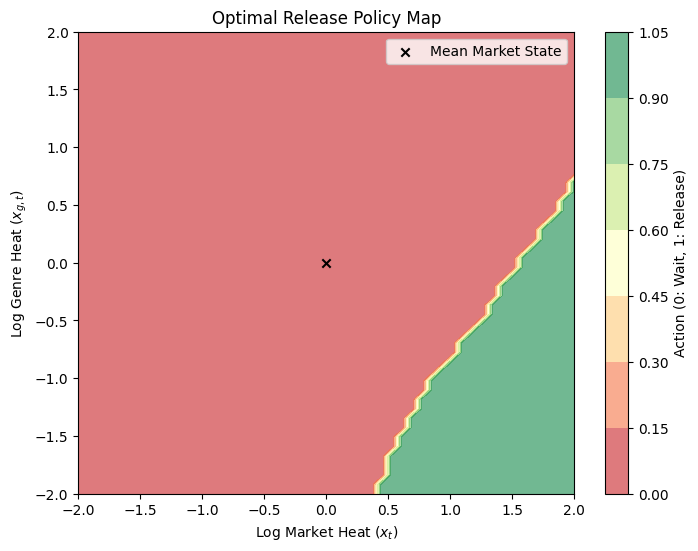

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_policy_map(agent, x_range=(-2, 2), g_range=(-2, 2), resolution=50):
    x = np.linspace(x_range[0], x_range[1], resolution)
    g = np.linspace(g_range[0], g_range[1], resolution)
    grid_x, grid_g = np.meshgrid(x, g)
    
    policy_grid = np.zeros_like(grid_x)
    
    agent.eval()
    with torch.no_grad():
        for i in range(resolution):
            for j in range(resolution):
                state = torch.tensor([grid_x[i,j], grid_g[i,j]], dtype=torch.float32)
                q_values = agent(state)
                policy_grid[i,j] = torch.argmax(q_values).item()

    plt.figure(figsize=(8, 6))
    plt.contourf(grid_x, grid_g, policy_grid, cmap='RdYlGn', alpha=0.6)
    plt.colorbar(label='Action (0: Wait, 1: Release)')
    plt.xlabel('Log Market Heat ($x_t$)')
    plt.ylabel('Log Genre Heat ($x_{g,t}$)')
    plt.title('Optimal Release Policy Map')
    
    # Add a marker for the steady state (0,0)
    plt.scatter([0], [0], color='black', marker='x', label='Mean Market State')
    plt.legend()
    plt.show()

plot_policy_map(agent)

To evaluate the model for your paper, you need to compare the RL Agent's Revenue against a Naive Baseline (e.g., "Release Immediately").

In [78]:
def run_diagnostics(env, agent, n_sims=500):
    rl_revenues = []
    immediate_revenues = []
    wait_times = []

    for _ in range(n_sims):
        # 1. Immediate Release Baseline
        initial_state = torch.tensor([0.0, 0.0]) # Start at mean
        _, imm_rev, _ = env.step(initial_state, 1, 0)
        immediate_revenues.append(imm_rev.item())

        # 2. RL Agent Simulation
        state = initial_state
        done = False
        age = 0
        while not done:
            action = agent.select_action(state, epsilon=0) # Greedy
            next_state, reward, done = env.step(state, action, age)
            if action == 1 or done:
                rl_revenues.append(reward.item() if action == 1 else 0)
                wait_times.append(age)
                break
            state = next_state
            age += 1

    print(f"--- Performance Results ---")
    print(f"Mean Immediate Release Revenue: {np.mean(immediate_revenues):.2f}")
    print(f"Mean RL Policy Revenue:         {np.mean(rl_revenues):.2f}")
    print(f"Average Wait Time:              {np.mean(wait_times):.1f} days")
    print(f"Lift Over Baseline:             {(np.mean(rl_revenues)/np.mean(immediate_revenues)-1)*100:.2f}%")

run_diagnostics(env, agent)

--- Performance Results ---
Mean Immediate Release Revenue: 96.34
Mean RL Policy Revenue:         223.70
Average Wait Time:              46.9 days
Lift Over Baseline:             132.19%


V. Conclusion & Discussion
* Comparison of the "AI Agent's" release timing versus the actual historical timing of labels.
* Discussion on the efficiency of the music market.
